In [31]:
import numpy as np
from pandas.plotting import lag_plot
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import sklearn as sk

[*********************100%***********************]  1 of 1 completed

Coefficients: [0.00463669]
Intercept: -0.04345878814408946
R-Squared: 0.0005156041459268845
Columns: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Close + 1', 'Target', 'RSI', 'Predicted', 'Residuals']  Index: [13, 14, 15, 16, 17]


Price,Adj Close,Close,High,Low,Open,Volume,Close + 1,Target,RSI,Predicted,Residuals
13,1.460667,1.460667,1.483333,1.394667,1.424667,37297500,1.353333,-7.348288,43.408794,0.157815,-7.506102
14,1.353333,1.353333,1.456667,1.336667,1.456667,27379500,1.348000,-0.394060,39.206237,0.138329,-0.532389
15,1.348000,1.348000,1.393333,1.300000,1.377333,18787500,1.400000,3.857561,39.159154,0.138110,3.719451
16,1.400000,1.400000,1.416667,1.358000,1.366667,14367000,1.419333,1.380929,46.915168,0.174073,1.206856
17,1.419333,1.419333,1.437333,1.404000,1.412667,9804000,1.396667,-1.596946,57.983173,0.225391,-1.822337
...,...,...,...,...,...,...,...,...,...,...,...
3962,371.750000,371.750000,373.329987,361.000000,361.510010,75534900,381.260010,2.558173,35.111035,0.119340,2.438833
3963,381.260010,381.260010,383.140015,374.079987,378.630005,58683800,360.589996,-5.421501,44.165324,0.161322,-5.582823
3964,360.589996,360.589996,370.279999,359.029999,364.200012,83031200,352.820007,-2.154799,38.636867,0.135689,-2.290487
3965,352.820007,352.820007,367.720001,346.640015,362.589996,77697600,346.649994,-1.748771,34.525714,0.116626,-1.865397


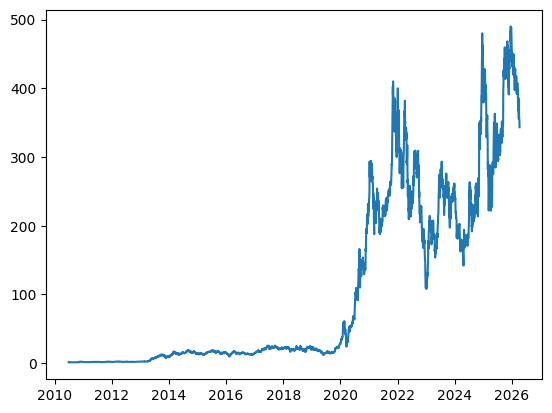

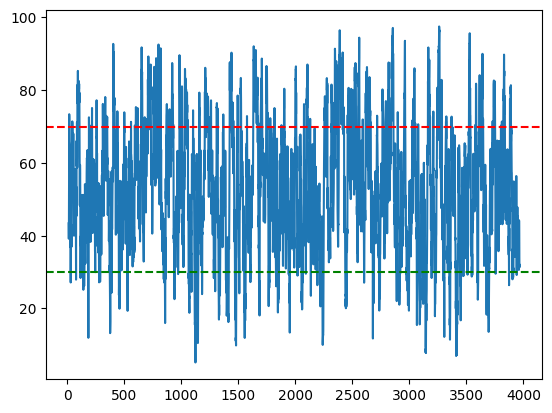

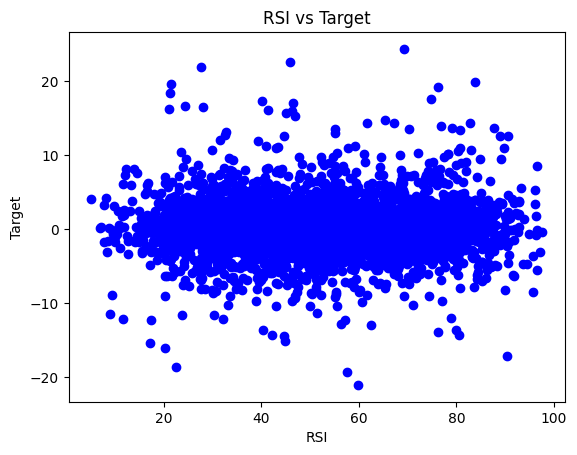

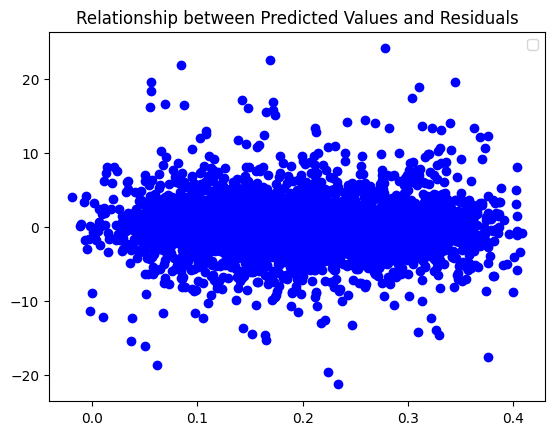

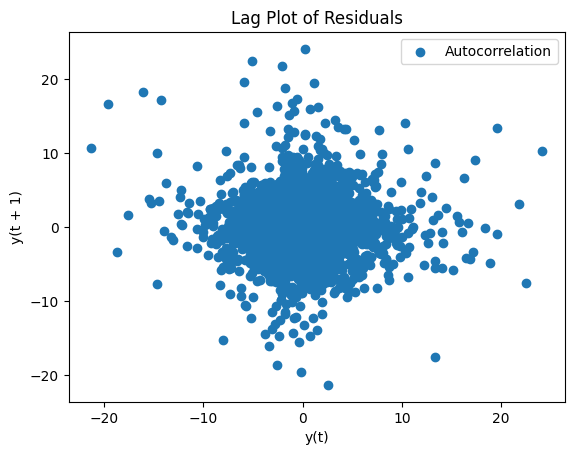

In [ ]:
TICKER = "TSLA"
INTERVAL = "1d"

# sey period based on interval
if INTERVAL == "1h":
    PERIOD = "730d"
else:
    PERIOD = "max"

SHIFT = 5
STRATEGY = 'RSI'
RSI_PERIOD = 14
OVERBOUGHT = 70
OVERSOLD = 30

#W what subsetion of the data to use for training and testing
LOOKBACK = 10000

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):
    
    # get data from yfinance    
    df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, auto_adjust=False)
    df.columns = df.columns.get_level_values(0)
    plt.plot(df['Close'])

    # reset index to get date as a column
    df = df.reset_index(drop=True)

    # only return the last LOOKBACK rows
    df = df.reset_index(drop=True)

    # only return the subset of the data specified by LOOKBACK
    return df.iloc[-LOOKBACK:, :]

# define the target variable as the closing price shifted by SHIFT
def add_target(df, shift=SHIFT):
    
    df[f'Close + {shift}'] = df['Close'].shift(-shift)

    df['Target'] = (df[f'Close + {shift}'] - df['Close']) / df['Close'] * 100

    return df

def add_RSI(df, period=RSI_PERIOD):
    price = df['Close'].diff()
    gain = price.where(price > 0, 0)
    loss = -price.where(price < 0, 0)

    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()

    rs = avg_gain / avg_loss
    RSI= 100 - (100 / (1 + rs))
    df['RSI'] = RSI

    plt.figure()
    plt.plot(df['RSI'])
    plt.axhline(OVERBOUGHT, color='red', linestyle='--')
    plt.axhline(OVERSOLD, color='green', linestyle='--')
    
    return df.dropna()

def generate_regression_output(df, features='RSI', target='Target'):
    
    subset = df[[features, target]].dropna()

    X = subset[features].values.reshape(-1, 1)
    y = subset[target].values

    model = sk.linear_model.LinearRegression()
    model.fit(X, y)
    
    predictions = model.predict(X)
    y_pred = model.predict(X)

    # what is the realtionship between the features and the target variable
    r2 = sk.metrics.r2_score(y, y_pred)

    # make coefficient variable
    coef  = model.coef_[0] 
    intercept = model.intercept_

    # coefficients of the linear regression model
    print(f"Coefficients: {coef}")
    print(f"Intercept: {intercept}")
    print(f"R-Squared: {r2}")

    plt.figure()
    plt.title(f"{features} vs {target}")
    plt.scatter(X, y, color='blue', label='Actual')
    plt.xlabel(f"{features}")
    plt.ylabel(f"{target}")


    return df, coef, intercept

def test_linearity_homoscedasticity(df, coef, intercept):

    # information necessary to plot the regression line
    df["Predicted"] = coef[0] * df[f'{STRATEGY}']+ intercept.squeeze()
    df['Residuals'] = df['Target'] - df['Predicted']

    plt.figure()
    plt.legend(['Curve Shape - Non-linear Relationship', 'Fanning - Heteroscedastic'])
    plt.scatter(df['Predicted'], df['Residuals'], color='blue')
    plt.title("Relationship between Predicted Values and Residuals")
    return df

def test_independence(df):
    print(f"Columns: {df.columns.tolist()}  Index: {df.index.tolist()[:5]}")
    plt.figure()
    log_plot(df['Residuals'].dropna())
    plt.title("Lag Plot of Residuals")
    
    return df




def main():
    df = get_data(TICKER)
    df = add_target(df)
    df = add_RSI(df)
    fit_coef, fit_intercept, r_squared = generate_regression_output(df)
    df = test_linearity(df, coef=fit_coef, intercept=fit_intercept)
    test_independence(df)

    return df

TICKER = "TSLA"
INTERVAL = "1d"

# sey period based on interval
if INTERVAL == "1h":
    PERIOD = "730d"
else:
    PERIOD = "max"

SHIFT = 1
STRATEGY = 'RSI'
RSI_PERIOD = 14
OVERBOUGHT = 70
OVERSOLD = 30

#W what subsetion of the data to use for training and testing
LOOKBACK = 50000

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):
    
    # get data from yfinance    
    df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, auto_adjust=False)
    df.columns = df.columns.get_level_values(0)
    plt.plot(df['Close'])

    # reset index to get date as a column
    df = df.reset_index(drop=True)

    # only return the last LOOKBACK rows
    df = df.reset_index(drop=True)

    # only return the subset of the data specified by LOOKBACK
    return df.iloc[-LOOKBACK:, :]

# define the target variable as the closing price shifted by SHIFT
def add_target(df, shift=SHIFT):
    
    df[f'Close + {shift}'] = df['Close'].shift(-shift)

    df['Target'] = (df[f'Close + {shift}'] - df['Close']) / df['Close'] * 100

    return df

def add_RSI(df, period=RSI_PERIOD):
    price = df['Close'].diff()
    gain = price.where(price > 0, 0)
    loss = -price.where(price < 0, 0)

    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()

    rs = avg_gain / avg_loss
    RSI= 100 - (100 / (1 + rs))
    df['RSI'] = RSI

    plt.figure()
    plt.plot(df['RSI'])
    plt.axhline(OVERBOUGHT, color='red', linestyle='--')
    plt.axhline(OVERSOLD, color='green', linestyle='--')
    
    return df.dropna()

def generate_regression_output(df, features='RSI', target='Target'):
    
    subset = df[[features, target]].dropna()

    X = subset[features].values.reshape(-1, 1)
    y = subset[target].values

    model = sk.linear_model.LinearRegression()
    model.fit(X, y)
    
    predictions = model.predict(X)
    y_pred = model.predict(X)

    # what is the realtionship between the features and the target variable
    r2 = sk.metrics.r2_score(y, y_pred)

    # make coefficient variable
    coef  = model.coef_
    intercept = model.intercept_

    # coefficients of the linear regression model
    print(f"Coefficients: {coef}")
    print(f"Intercept: {intercept}")
    print(f"R-Squared: {r2}")

    plt.figure()
    plt.title(f"{features} vs {target}")
    plt.scatter(X, y, color='blue', label='Actual')
    plt.xlabel(f"{features}")
    plt.ylabel(f"{target}")


    return df, coef, intercept, r2

def test_linearity_homoscedasticity(df, coef, intercept):

    # information necessary to plot the regression line
    df["Predicted"] = coef[0] * df[f'{STRATEGY}']+ intercept.squeeze()
    df['Residuals'] = df['Target'] - df['Predicted']

    plt.figure()
    plt.legend(['Curve Shape - Non-linear Relationship', 'Fanning - Heteroscedastic'])
    plt.scatter(df['Predicted'], df['Residuals'], color='blue')
    plt.title("Relationship between Predicted Values and Residuals")
    return df


def test_independence(df):
    print(f"Columns: {df.columns.tolist()}  Index: {df.index.tolist()[:5]}")
    plt.figure()
    lag_plot(df['Residuals'].dropna())
    plt.legend(['Autocorrelation', 'Independence'])
    plt.title("Lag Plot of Residuals")
    
    return df

def test_normality(df):

    plt.figure()
    plt.hist(df['Residuals '])

    return df


def main():
    df = get_data(TICKER)
    df = add_target(df)
    df = add_RSI(df)
    df, fit_coef, fit_intercept, r_squared = generate_regression_output(df)
    df = test_linearity_homoscedasticity(df, coef=fit_coef, intercept=fit_intercept)
    test_independence(df)

    return df

df = main()
df
df